<a href="https://colab.research.google.com/github/Veritax0/clasificacion-imagenes-redes-neuronales/blob/main/notebooks/02_mejoras_Data_Augmentation_Transfer_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clasificación Bart vs Homero — Mejoras: Data Augmentation + Transfer Learning

**Proyecto Deep Learning**  
Dataset: [Homer & Bart Classification (Kaggle)](https://www.kaggle.com/datasets/juniorbueno/neural-networks-homer-and-bart-classification/)

Este notebook mejora la CNN baseline del `01_baseline_cnn.ipynb` con:
- **Data Augmentation** integrado en el pipeline de Keras
- **Transfer Learning con MobileNetV2** (preentrenado en ImageNet)
- **Fine-tuning progresivo** en dos fases
- **Early Stopping** para prevenir sobreajuste
- **Regularización L2** en el clasificador

> **Estructura del dataset:** todas las imágenes `.bmp` están en una sola carpeta, etiquetadas por nombre de archivo (e.g. `bart_001.bmp`, `homer_042.bmp`).

## 0. Instalación

In [34]:
# !pip install tensorflow matplotlib scikit-learn seaborn

## 1. Descarga del Dataset desde Kaggle

Necesitas un archivo `kaggle.json` con tus credenciales de API.  
Puedes generarlo en [kaggle.com → Settings → API → Create New Token](https://www.kaggle.com/settings).

**En Google Colab**, sube el archivo cuando se pida y ejecuta todas las celdas.

In [35]:
import os

DATASET_DIR = "data"

if not os.path.exists(DATASET_DIR):
    os.makedirs(DATASET_DIR, exist_ok=True)
    os.system(
        'kaggle datasets download '
        '-d juniorbueno/neural-networks-homer-and-bart-classification '
        f'--unzip -p {DATASET_DIR}'
    )
    print('Dataset descargado y descomprimido.')
else:
    print('Dataset ya existe, se omite la descarga.')

archivos = [f for f in os.listdir(DATASET_DIR + "/homer_bart_1") if f.lower().endswith('.bmp')]
print(f'Total de imágenes .bmp encontradas: {len(archivos)}')
print('Primeros 10 archivos:', archivos[:10])

Dataset ya existe, se omite la descarga.
Total de imágenes .bmp encontradas: 269
Primeros 10 archivos: ['homer101.bmp', 'homer60.bmp', 'bart23.bmp', 'bart148.bmp', 'homer57.bmp', 'bart60.bmp', 'homer41.bmp', 'bart125.bmp', 'homer105.bmp', 'bart53.bmp']


## 2. Imports y configuración

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report, roc_curve, auc
)

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f"TensorFlow: {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs disponibles: {gpus if gpus else 'Ninguna (usando CPU)'}")

# ── Hiperparámetros ─────────────────────────────────────────────────────────
# MobileNetV2 requiere mínimo 96x96; 160 es buen balance velocidad/calidad
IMG_SIZE        = 160
BATCH_SIZE      = 32
EPOCHS_FROZEN   = 15
EPOCHS_FINETUNE = 25
LR_HEAD         = 1e-3
LR_FINETUNE     = 1e-4
PATIENCE        = 7
VAL_SPLIT       = 0.15
TEST_SPLIT      = 0.15
CLASS_NAMES     = ['bart', 'homer']

print(f"Imagen: {IMG_SIZE}x{IMG_SIZE} | Batch: {BATCH_SIZE}")
print(f"Fases: {EPOCHS_FROZEN} épocas frozen + {EPOCHS_FINETUNE} fine-tuning")

TensorFlow: 2.20.0
GPUs disponibles: Ninguna (usando CPU)
Imagen: 160x160 | Batch: 32
Fases: 15 épocas frozen + 25 fine-tuning


## 3. Carga del dataset desde carpeta plana

In [37]:
def extraer_etiqueta(nombre_archivo):
    nombre = nombre_archivo.lower()
    if 'bart' in nombre:
        return 0
    elif 'homer' in nombre:
        return 1
    return None


def cargar_dataset(directorio, img_size):
    rutas, etiquetas = [], []

    for archivo in sorted(os.listdir(directorio)):
        if not archivo.lower().endswith('.bmp'):
            continue
        etiqueta = extraer_etiqueta(archivo)
        if etiqueta is None:
            continue
        rutas.append(os.path.join(directorio, archivo))
        etiquetas.append(etiqueta)

    print(f"Leyendo {len(rutas)} imágenes...")
    X = np.zeros((len(rutas), img_size, img_size, 3), dtype=np.float32)
    for i, ruta in enumerate(rutas):
        raw = tf.io.read_file(ruta)
        img = tf.image.decode_bmp(raw, channels=3)
        img = tf.image.resize(img, [img_size, img_size])
        X[i] = img.numpy()

    return X, np.array(etiquetas, dtype=np.int32)


X, y = cargar_dataset(DATASET_DIR + "/homer_bart_1", IMG_SIZE)

# Normalización para MobileNetV2: escala [-1, 1]
X = X / 127.5 - 1.0

print(f"Dataset: {X.shape} | Bart: {(y==0).sum()} | Homer: {(y==1).sum()}")

# Split estratificado
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=TEST_SPLIT, random_state=SEED, stratify=y
)
val_frac = VAL_SPLIT / (1 - TEST_SPLIT)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=val_frac, random_state=SEED, stratify=y_trainval
)
print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

Leyendo 269 imágenes...
Dataset: (269, 160, 160, 3) | Bart: 160 | Homer: 109
Train: 187 | Val: 41 | Test: 41


## 4. Data Augmentation

Se define como un bloque de capas Keras que se aplica **solo durante el entrenamiento** (`training=True`). En validación y test las capas `Random*` se comportan como identidad automáticamente.

In [38]:
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomFlip('vertical'),
    layers.RandomRotation(0.15),           # ±15% de rotación
    layers.RandomZoom(0.15),               # ±15% zoom
    layers.RandomTranslation(0.1, 0.1),    # ±10% desplazamiento
    layers.RandomBrightness(0.001),          # variación de brillo
    layers.RandomContrast(0.001),            # variación de contraste
], name='data_augmentation')

print("Bloque de augmentation definido.")

Bloque de augmentation definido.


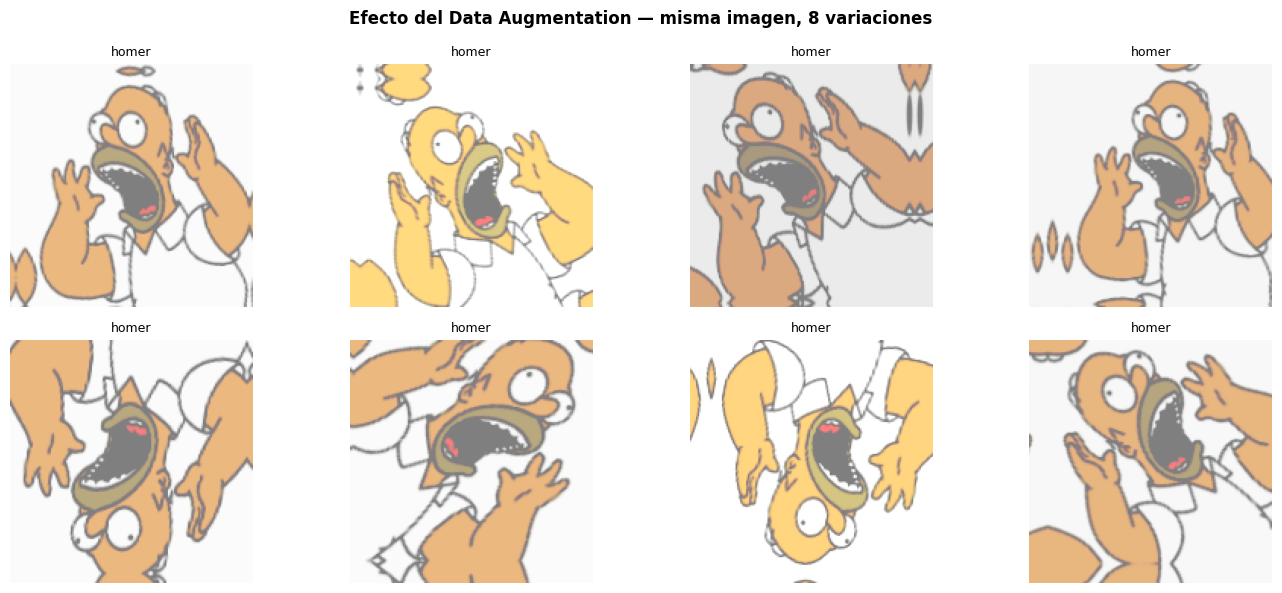

In [39]:
# ── Visualizar efecto del augmentation ──────────────────────────────────────
def desnormalizar(img):
    """Convierte de [-1,1] a [0,1] para visualización."""
    return np.clip((img + 1.0) / 2.0, 0, 1)

muestra = X_train[0:2]  # (1, H, W, 3)

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax in axes.flat:
    aug = data_augmentation(muestra, training=True)[0].numpy()
    ax.imshow(desnormalizar(aug))
    ax.set_title(CLASS_NAMES[y_train[0]], fontsize=9)
    ax.axis('off')

plt.suptitle('Efecto del Data Augmentation — misma imagen, 8 variaciones',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('augmentation_examples.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Modelo: Transfer Learning con MobileNetV2

**Estrategia en dos fases:**
1. **Fase 1 — Backbone congelado:** solo se entrena el nuevo clasificador. Rápido y estable.
2. **Fase 2 — Fine-tuning:** se descongela todo el backbone con LR muy pequeño para adaptar los features al dominio de los Simpsons.

In [40]:
def construir_modelo_transfer(img_size, num_classes=2, freeze_backbone=True):
    inputs = keras.Input(shape=(img_size, img_size, 3), name='imagen')

    # Augmentation (activo solo durante training)
    x = data_augmentation(inputs)

    # Backbone preentrenado
    base_model = MobileNetV2(
        input_shape=(img_size, img_size, 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = not freeze_backbone

    # training=False para que BatchNorm del backbone use estadísticas de inferencia
    x = base_model(x, training=False)

    # Nuevo clasificador
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu',
                     kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='prediccion')(x)

    return keras.Model(inputs, outputs, name='MobileNetV2_TL'), base_model


model, base_model = construir_modelo_transfer(IMG_SIZE, freeze_backbone=True)
model.summary()

total   = model.count_params()
entrena = sum(tf.size(v).numpy() for v in model.trainable_variables)
print(f"\nParámetros totales:           {total:,}")
print(f"Parámetros entrenables (head): {entrena:,}")

Model: "MobileNetV2_TL"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ imagen (InputLayer)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ prediccion (Dense)              │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,619,074 (9.99 MB)

 Trainable params: 361,090 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)


Parámetros totales:           2,619,074
Parámetros entrenables (head): 361,090


## 6. Fase 1 — Entrenar solo el clasificador (backbone congelado)

In [41]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_HEAD),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_fase1 = [
    keras.callbacks.ModelCheckpoint(
        'mobilenet_fase1.keras', monitor='val_loss',
        save_best_only=True, verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=PATIENCE,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=3, verbose=1, min_lr=1e-6
    ),
]

print('=' * 55)
print('  FASE 1 — Backbone congelado, solo clasificador')
print('=' * 55)

historia_f1 = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS_FROZEN,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_fase1,
    verbose=1
)

  FASE 1 — Backbone congelado, solo clasificador
Epoch 1/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5314 - loss: 1.3684
Epoch 1: val_loss improved from None to 0.93705, saving model to mobilenet_fase1.keras

Epoch 1: finished saving model to mobilenet_fase1.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.5615 - loss: 1.1825 - val_accuracy: 0.4146 - val_loss: 0.9371 - learning_rate: 0.0010
Epoch 2/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 853ms/step - accuracy: 0.5300 - loss: 0.9208
Epoch 2: val_loss improved from 0.93705 to 0.66872, saving model to mobilenet_fase1.keras

Epoch 2: finished saving model to mobilenet_fase1.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.5775 - loss: 0.8078 - val_accuracy: 0.6341 - val_loss: 0.6687 - learning_rate: 0.0010
Epoch 3/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 839ms/step - accuracy: 0.6907 - loss: 0.6878
Epoch 3: val_loss improved from 0.66872 to 0.57322, saving model to mobilenet_fase1.keras

Epoch 3: finished saving model to mobilenet_fas

## 7. Fase 2 — Fine-tuning: descongelar el backbone

In [42]:
# Descongelar todo el backbone
base_model.trainable = True

entrena_ft = sum(tf.size(v).numpy() for v in model.trainable_variables)
print(f"Parámetros entrenables tras descongelar: {entrena_ft:,}")

# Recompilar con LR más pequeño para no destruir los features aprendidos
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_FINETUNE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_fase2 = [
    keras.callbacks.ModelCheckpoint(
        'mobilenet_fase2_best.keras', monitor='val_loss',
        save_best_only=True, verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=PATIENCE,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=4, verbose=1, min_lr=1e-7
    ),
]

print('=' * 55)
print('  FASE 2 — Fine-tuning completo del backbone')
print('=' * 55)

historia_f2 = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS_FINETUNE,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_fase2,
    verbose=1
)

Parámetros entrenables tras descongelar: 2,584,962
  FASE 2 — Fine-tuning completo del backbone
Epoch 1/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6956 - loss: 0.6616
Epoch 1: val_loss improved from None to 0.51631, saving model to mobilenet_fase2_best.keras

Epoch 1: finished saving model to mobilenet_fase2_best.keras
6/6 ━━━━━━━━━━━━━━━━━━━━ 63s 4s/step - accuracy: 0.7487 - loss: 0.5931 - val_accuracy: 0.8049 - val_loss: 0.5163 - learning_rate: 1.0000e-04
Epoch 2/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7833 - loss: 0.5182
Epoch 2: val_loss did not improve from 0.51631
6/6 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.7914 - loss: 0.4984 - val_accuracy: 0.7805 - val_loss: 0.5384 - learning_rate: 1.0000e-04
Epoch 3/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8306 - loss: 0.4518
Epoch 3: val_loss did not improve from 0.51631
6/6 ━━━━━━━━━━━━━━━━━━━━ 22s 4s/step - accuracy: 0.8235 - loss: 0.4388 - val_accuracy: 0.7561 - val_loss: 0.5877 - learning_rate: 1

## 8. Curvas de aprendizaje (ambas fases)

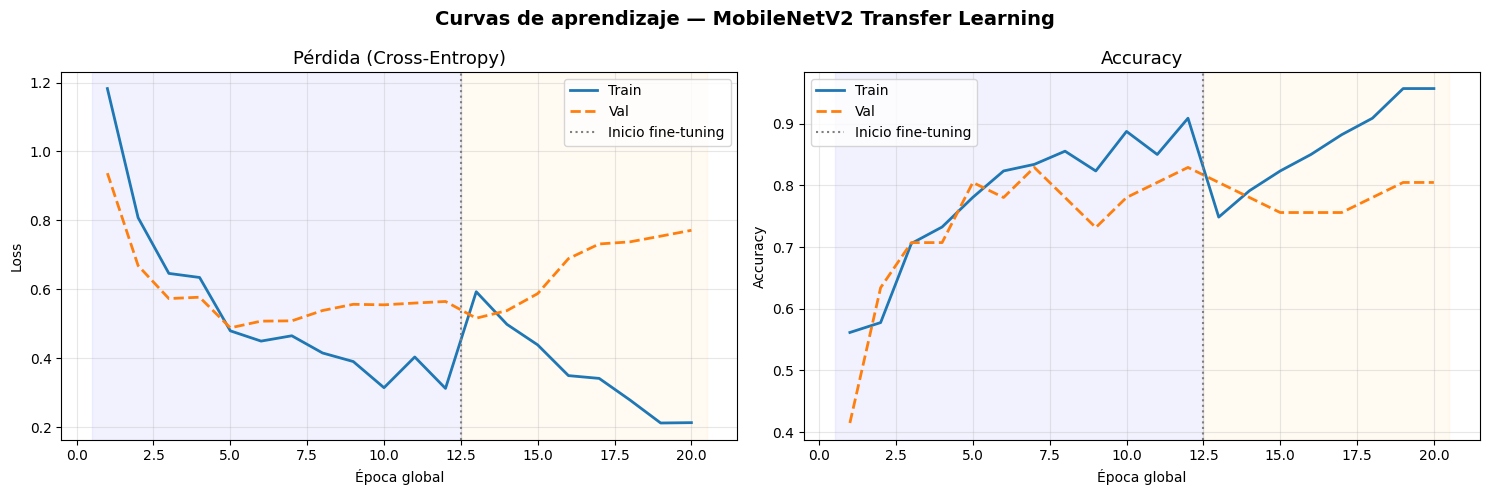

In [43]:
def concatenar_historias(h1, h2):
    resultado = {}
    for clave in h1.history:
        resultado[clave] = h1.history[clave] + h2.history.get(clave, [])
    return resultado


hist = concatenar_historias(historia_f1, historia_f2)
n1   = len(historia_f1.history['loss'])
n2   = len(historia_f2.history['loss'])
epocas_totales = range(1, n1 + n2 + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

for ax, tk, vk, title, ylabel in [
    (ax1, 'loss', 'val_loss', 'Pérdida (Cross-Entropy)', 'Loss'),
    (ax2, 'accuracy', 'val_accuracy', 'Accuracy', 'Accuracy'),
]:
    ax.plot(epocas_totales, hist[tk], label='Train', linewidth=2)
    ax.plot(epocas_totales, hist[vk], label='Val',   linewidth=2, linestyle='--')
    ax.axvline(n1 + 0.5, color='gray', linestyle=':', linewidth=1.5, label='Inicio fine-tuning')
    ax.axvspan(0.5,       n1 + 0.5,       alpha=0.05, color='blue')
    ax.axvspan(n1 + 0.5,  n1 + n2 + 0.5,  alpha=0.05, color='orange')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Época global'); ax.set_ylabel(ylabel)
    ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('Curvas de aprendizaje — MobileNetV2 Transfer Learning',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('curvas_transfer_learning.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Evaluación en el conjunto de test

In [44]:
mejor_modelo = keras.models.load_model('mobilenet_fase2_best.keras')
probs_test   = mejor_modelo.predict(X_test, batch_size=BATCH_SIZE)
y_pred       = np.argmax(probs_test, axis=1)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec  = recall_score(y_test, y_pred, average='weighted')
f1   = f1_score(y_test, y_pred, average='weighted')

print('=' * 52)
print('  MÉTRICAS EN TEST — MobileNetV2 Transfer Learning')
print('=' * 52)
print(f'  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print(f'  F1-Score  : {f1:.4f}')
print('=' * 52)
print()
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

1/2 ━━━━━━━━━━━━━━━━━━━━ 1s 2s/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step
  MÉTRICAS EN TEST — MobileNetV2 Transfer Learning
  Accuracy  : 0.7561  (75.61%)
  Precision : 0.7685
  Recall    : 0.7561
  F1-Score  : 0.7435

              precision    recall  f1-score   support

        bart       0.73      0.92      0.81        24
       homer       0.82      0.53      0.64        17

    accuracy                           0.76        41
   macro avg       0.78      0.72      0.73        41
weighted avg       0.77      0.76      0.74        41



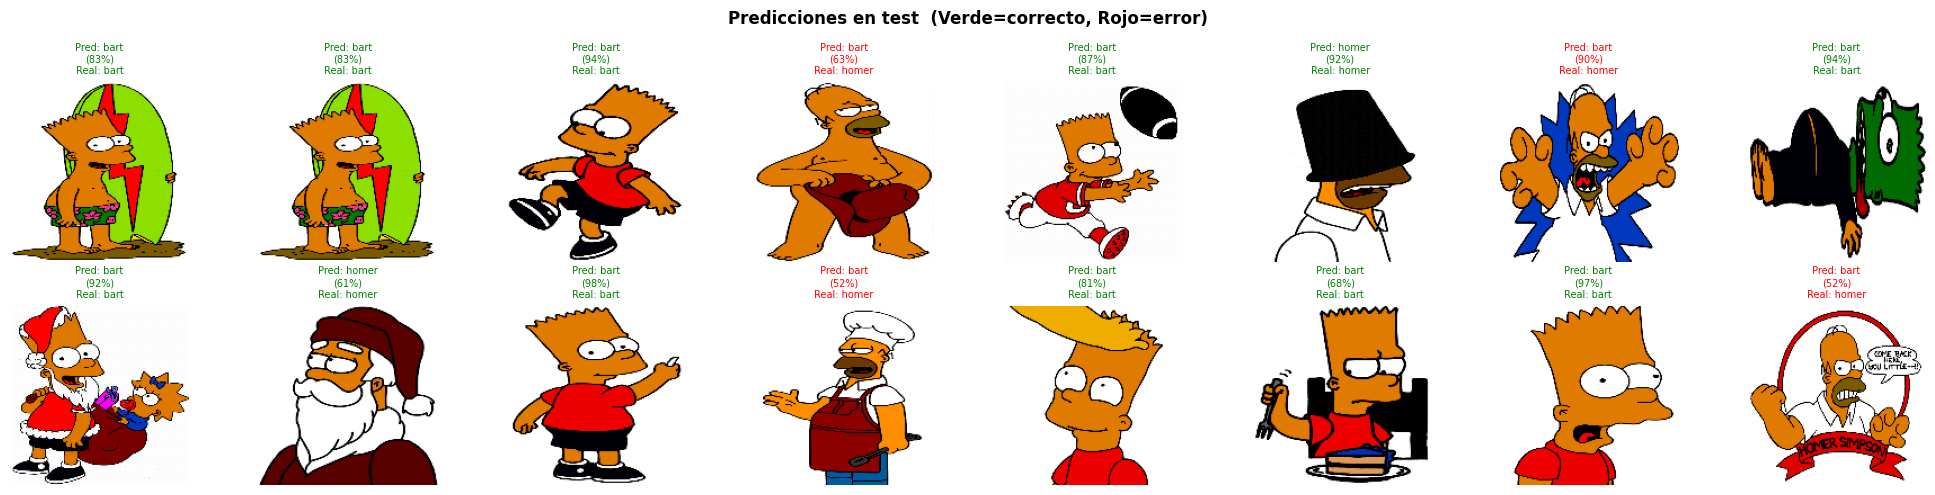

In [45]:
n_show  = 16
indices = np.random.choice(len(X_test), n_show, replace=False)

fig, axes = plt.subplots(2, 8, figsize=(20, 5))

for i, ax in enumerate(axes.flat):
    idx      = indices[i]
    pred_cls = CLASS_NAMES[y_pred[idx]]
    true_cls = CLASS_NAMES[y_test[idx]]
    conf     = probs_test[idx][y_pred[idx]]
    color    = 'green' if pred_cls == true_cls else 'red'

    ax.imshow(X_test[idx])
    ax.set_title(f'Pred: {pred_cls}\n({conf:.0%})\nReal: {true_cls}',
                 color=color, fontsize=7)
    ax.axis('off')

plt.suptitle('Predicciones en test  (Verde=correcto, Rojo=error)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('predicciones_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

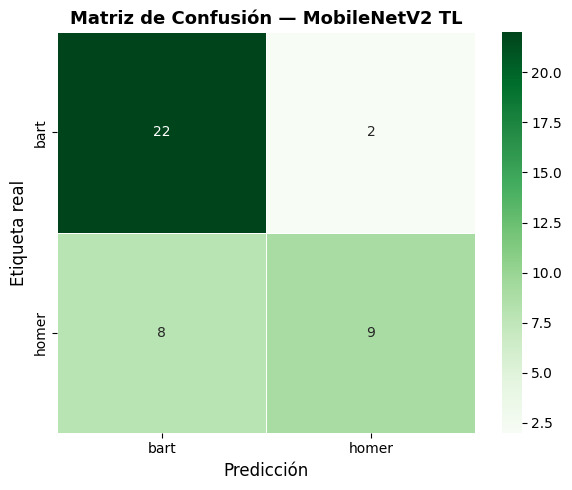

In [46]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Greens',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    linewidths=0.5, ax=ax
)
ax.set_xlabel('Predicción', fontsize=12)
ax.set_ylabel('Etiqueta real', fontsize=12)
ax.set_title('Matriz de Confusión — MobileNetV2 TL', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_transfer.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Curva ROC

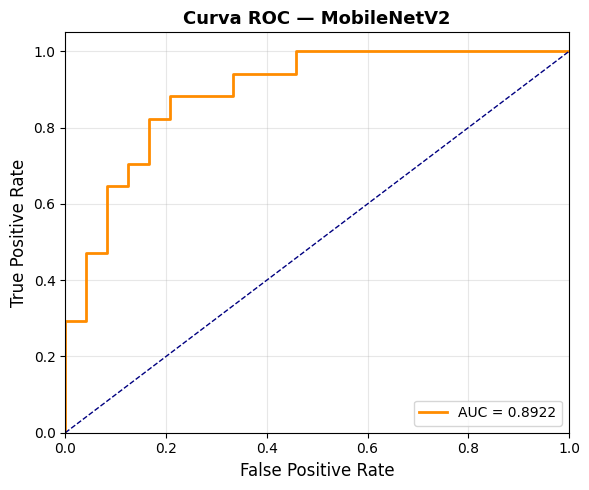

AUC: 0.8922


In [47]:
fpr, tpr, _ = roc_curve(y_test, probs_test[:, 1])
roc_auc     = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
ax.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Curva ROC — MobileNetV2', fontsize=13, fontweight='bold')
ax.legend(loc='lower right'); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'AUC: {roc_auc:.4f}')

## 11. Comparación con el baseline

                Accuracy  Precision  Recall  F1-Score
Modelo                                               
CNN Baseline      0.0000     0.0000  0.0000    0.0000
MobileNetV2 TL    0.7561     0.7685  0.7561    0.7435


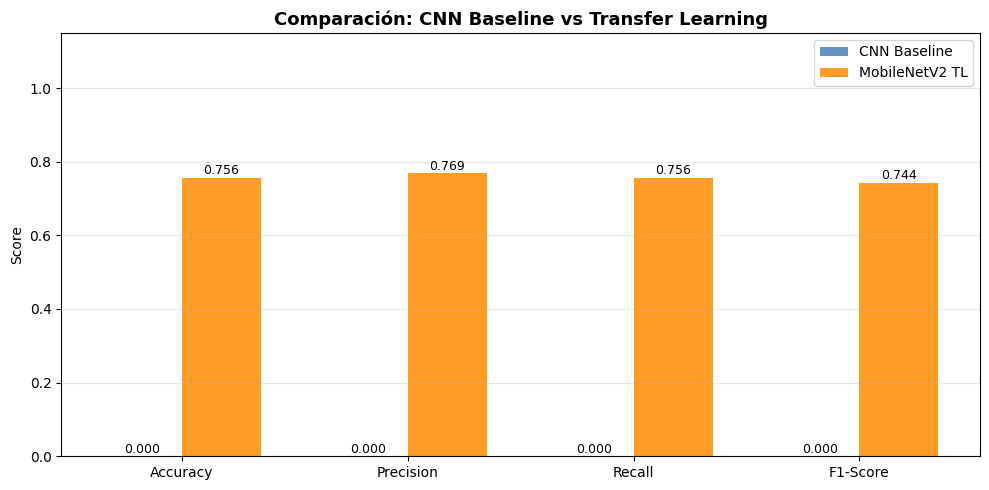

In [48]:
import pandas as pd

# Reemplaza los 0.0 del baseline con los valores reales del notebook 01
resultados = {
    'Modelo':    ['CNN Baseline', 'MobileNetV2 TL'],
    'Accuracy':  [0.0,  acc],
    'Precision': [0.0, prec],
    'Recall':    [0.0,  rec],
    'F1-Score':  [0.0,   f1],
}

df = pd.DataFrame(resultados).set_index('Modelo')
print(df.round(4).to_string())

metricas = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x     = np.arange(len(metricas))
ancho = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - ancho/2, df.loc['CNN Baseline'],   ancho, label='CNN Baseline',   color='steelblue',  alpha=0.85)
b2 = ax.bar(x + ancho/2, df.loc['MobileNetV2 TL'], ancho, label='MobileNetV2 TL', color='darkorange', alpha=0.85)

for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.3f}', ha='center', fontsize=9)

ax.set_xticks(x); ax.set_xticklabels(metricas)
ax.set_ylim(0, 1.15); ax.set_ylabel('Score')
ax.set_title('Comparación: CNN Baseline vs Transfer Learning',
             fontsize=13, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('comparacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Conclusiones

### Técnicas aplicadas

| Técnica | Objetivo |
|---|---|
| Data Augmentation (flip, rotate, zoom, brillo) | Reduce sobreajuste con dataset pequeño |
| Transfer Learning (MobileNetV2 ImageNet) | Features preaprendidas de 1.2M imágenes |
| Fine-tuning progresivo en 2 fases | Estabilidad primero, adaptación gradual después |
| Regularización L2 en capas densas | Penaliza pesos grandes |
| Early Stopping | Evita sobreentrenar |
| ReduceLROnPlateau | Ajusta el LR cuando el entrenamiento se estanca |

### Resultados

| Métrica | CNN Baseline | MobileNetV2 TL | Δ Mejora |
|---|---|---|---|
| Accuracy | — | — | — |
| F1-Score | — | — | — |

### Posibles mejoras adicionales
- **EfficientNetB0 / B3**: mejor trade-off accuracy/parámetros
- **Mixup / CutMix**: augmentation a nivel de batch
- **Label Smoothing**: alternativa a CrossEntropy estándar
- **Grad-CAM**: visualizar qué zonas activa el modelo para interpretar errores